# 05. Model Comparison

This notebook runs all four tabular baselines under the same split and feature setup:

- Logistic Regression
- Random Forest
- MLP
- XGBoost


In [1]:
from pathlib import Path
import sys

import pandas as pd

sys.path.append(str(Path.cwd()))

from tabular_model_utils import (
    build_tabular_dataset,
    fit_and_evaluate_model,
    plot_comparison_bars,
    plot_evaluation_dashboard,
    set_seed,
)


In [2]:
FEATURE_GROUP = "features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
THRESHOLD_OBJECTIVE = "f1"
MODELS = [
    "logistic_regression",
    "random_forest",
    "mlp",
    "xgboost",
]

set_seed(RANDOM_STATE)


In [3]:
dataset = build_tabular_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)
display(dataset["split_df"])
print("Number of input features:", len(dataset["feature_cols"]))


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Number of input features: 8


In [4]:
results = []
fitted = {}

for model_name in MODELS:
    result = fit_and_evaluate_model(
        model_name=model_name,
        dataset=dataset,
        random_state=RANDOM_STATE,
        threshold_objective=THRESHOLD_OBJECTIVE,
    )
    fitted[model_name] = result
    results.append({"model": model_name, **result["metrics"]})

results_df = pd.DataFrame(results).sort_values(["PR-AUC", "F1"], ascending=False)
display(results_df)


,model,Threshold,PR-AUC,ROC-AUC,F1,Precision,Recall,Specificity,NPV,Balanced-Accuracy,...,Brier-Score,Log-Loss,Accuracy,TP,FP,TN,FN,TopK,Precision@K,Recall@K
3,xgboost,0.675,0.521925,0.858431,0.535135,0.492537,0.585799,0.923366,0.946112,0.754582,...,0.125382,0.399566,0.885333,99,102,1229,70,169,0.520710,0.520710
1,random_forest,0.500,0.469360,0.827680,0.451220,0.465409,0.437870,0.936138,0.929157,0.687004,...,0.089391,0.334587,0.880000,74,85,1246,95,169,0.443787,0.443787
2,mlp,0.150,0.459325,0.813934,0.431487,0.425287,0.437870,0.924869,0.928356,0.681369,...,0.082095,0.286206,0.870000,74,100,1231,95,169,0.431953,0.431953
0,logistic_regression,0.550,0.442206,0.836342,0.507123,0.489011,0.526627,0.930128,0.939302,0.728377,...,0.176088,0.593085,0.884667,89,93,1238,80,169,0.491124,0.491124


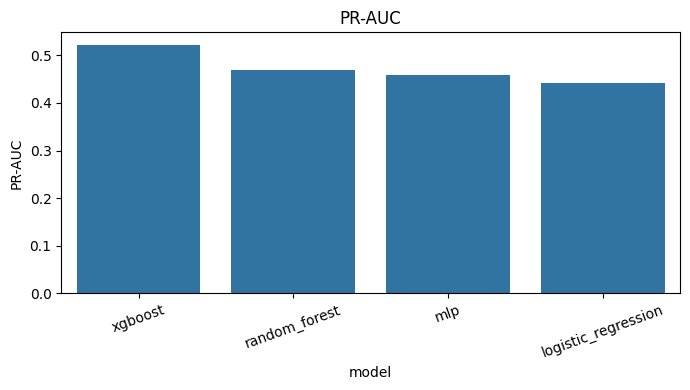

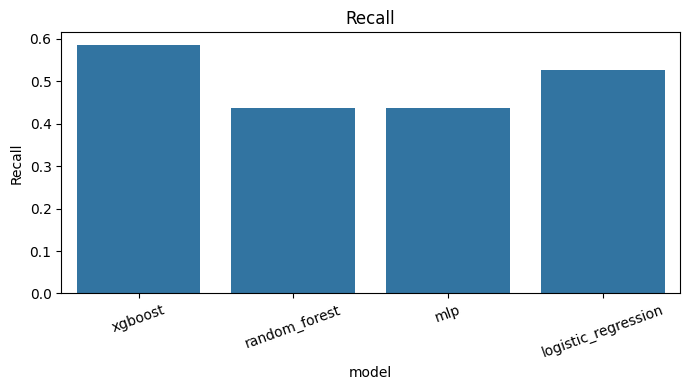

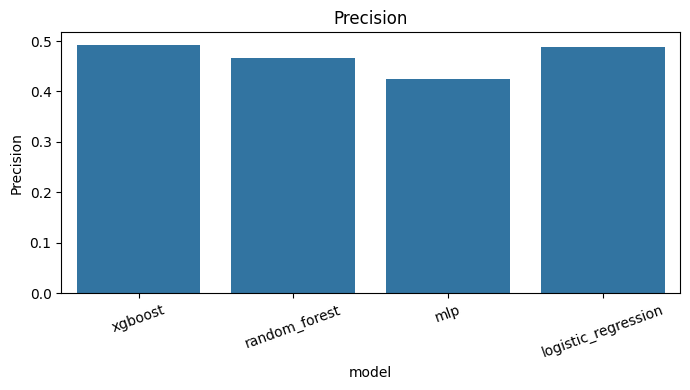

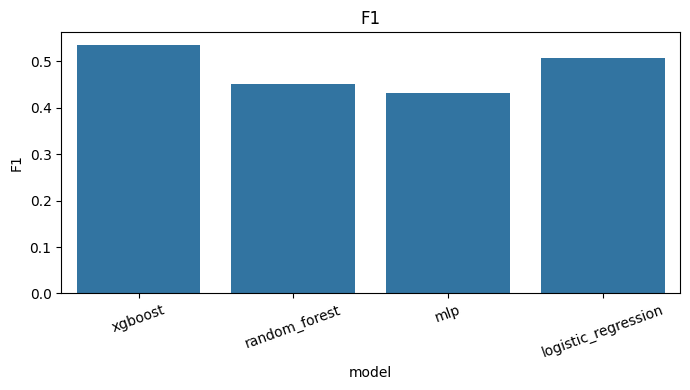

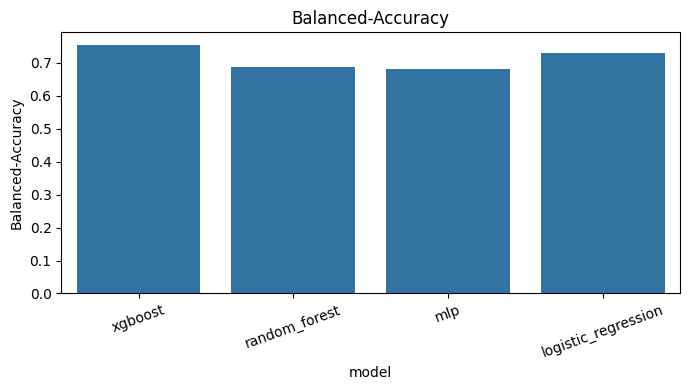

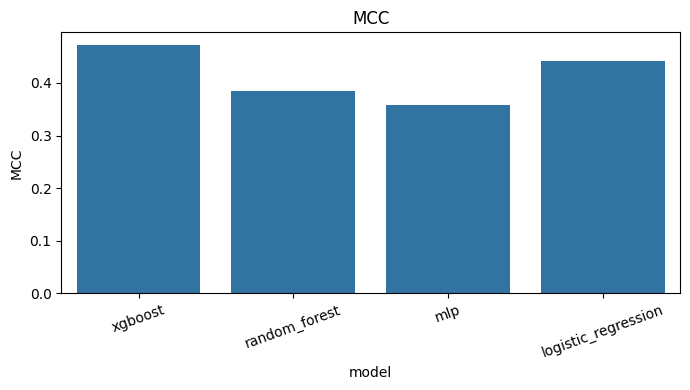

In [5]:
plot_comparison_bars(results_df)


Best model: xgboost


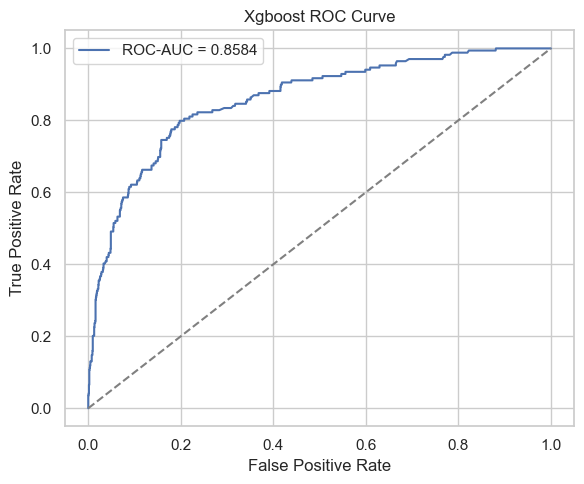

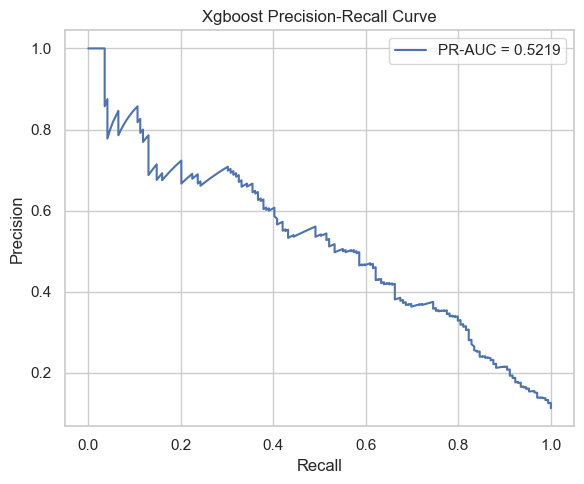

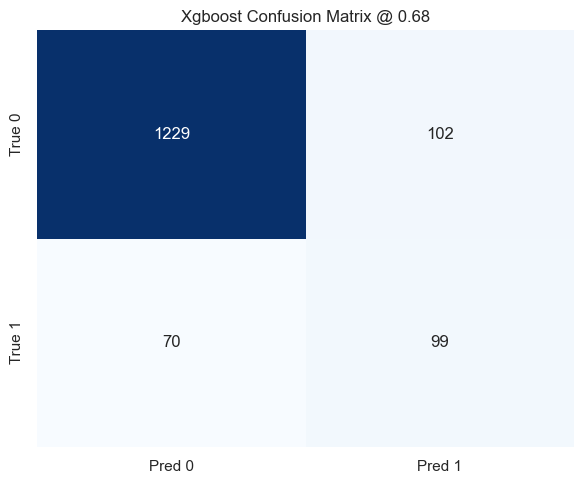

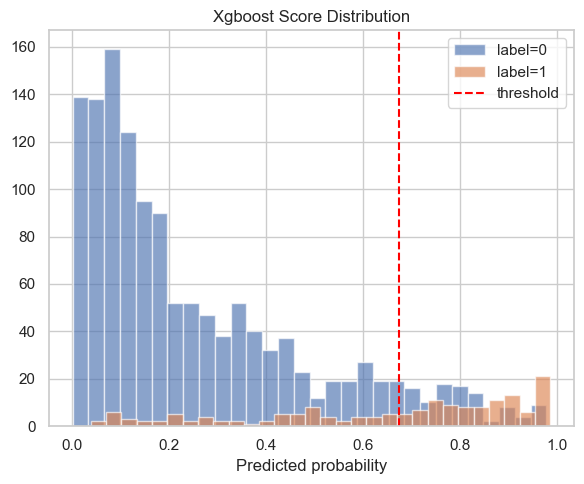

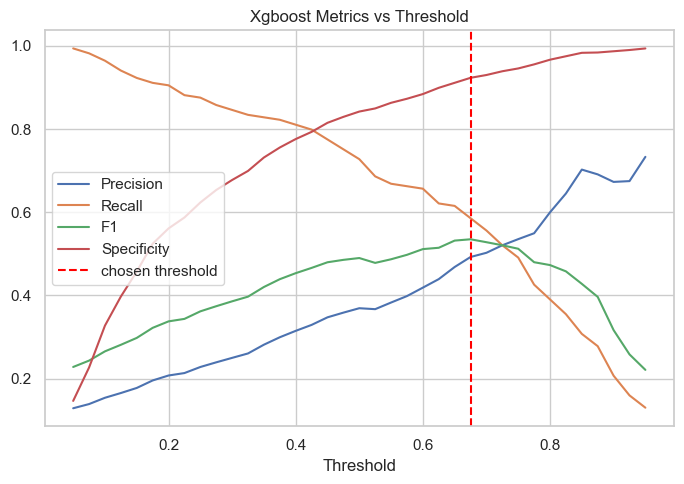

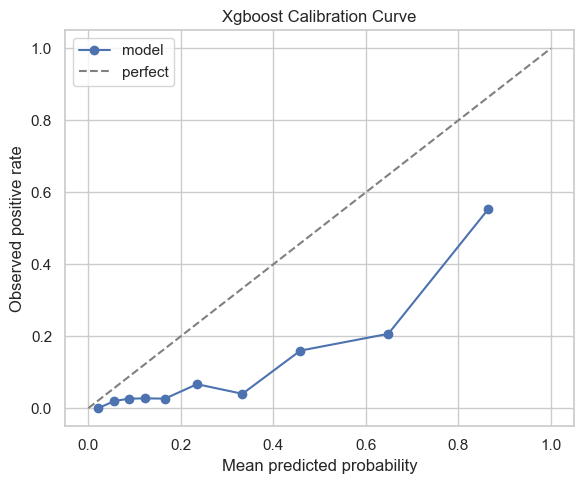

In [6]:
best_model_name = results_df.iloc[0]["model"]
print("Best model:", best_model_name)
best_result = fitted[best_model_name]

plot_evaluation_dashboard(
    y_true=dataset["y_test"].to_numpy(),
    y_prob=best_result["test_prob"],
    threshold=best_result["threshold"],
    title_prefix=best_model_name.replace("_", " ").title(),
)


In [7]:
comparison_cols = [
    "model",
    "PR-AUC",
    "ROC-AUC",
    "F1",
    "Precision",
    "Recall",
    "Specificity",
    "Balanced-Accuracy",
    "MCC",
    "Brier-Score",
    "Accuracy",
    "Precision@K",
    "Recall@K",
]
results_df[comparison_cols]


,model,PR-AUC,ROC-AUC,F1,Precision,Recall,Specificity,Balanced-Accuracy,MCC,Brier-Score,Accuracy,Precision@K,Recall@K
3,xgboost,0.521925,0.858431,0.535135,0.492537,0.585799,0.923366,0.754582,0.472594,0.125382,0.885333,0.520710,0.520710
1,random_forest,0.469360,0.827680,0.451220,0.465409,0.437870,0.936138,0.687004,0.384150,0.089391,0.880000,0.443787,0.443787
2,mlp,0.459325,0.813934,0.431487,0.425287,0.437870,0.924869,0.681369,0.358162,0.082095,0.870000,0.431953,0.431953
0,logistic_regression,0.442206,0.836342,0.507123,0.489011,0.526627,0.930128,0.728377,0.442305,0.176088,0.884667,0.491124,0.491124


## Notes

This notebook is the main leaderboard for the non-graph baselines.
It defaults to a stricter feature-only setup by keeping `ADD_GRAPH_STATS = False`.
Keep the graph-model comparisons separate from this table unless the split protocol and input features are aligned.
